In [1]:
import tensorflow as tf
import tensorflow.data as tfd
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import fnmatch
import cv2
# import other libraries
from keras.layers import Dense, LSTM, Reshape, Input, Conv2D, MaxPool2D, Dropout, Bidirectional
from keras.preprocessing.sequence import pad_sequences
import os
import numpy as np
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.image as implt
from IPython.display import clear_output as cls

2024-12-08 17:31:21.051330: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-08 17:31:21.054207: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-08 17:31:21.162651: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-08 17:31:21.687374: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-08 17:31:23.327561: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF

In [2]:
path = "/home/saurav/Downloads/mjsynth/mnt/ramdisk/max/90kDICT32px/imlist.txt"
with open(path) as af:
    txt = af.readlines()

req = []
for i in txt:
    req.append(i.split("_")[1])



print(len(req))

8919273


In [3]:
char_list = set(char for word in req for char in word)
n_classes = len(char_list)
result = ''.join(sorted(char_list))
result

'0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'

In [4]:
IMG_WIDTH = 128
IMG_HEIGHT = 32
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-3
MODEL_NAME = "CharacterRecognition-Model.keras"
TRAIN_SIZE = BATCH_SIZE * 3000
VALID_SIZE = BATCH_SIZE * 1500
TEST_SIZE  = BATCH_SIZE * 300
AUTOTUNE = tfd.AUTOTUNE

# Training callbacks 
CALLBACKS = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath=MODEL_NAME , save_best_only=True)
]

In [5]:
import string


char_list = result

print(char_list)

def encode_to_labels(txt):
    dig_lst = []
    for index, char in enumerate(txt):
        try:
            dig_lst.append(char_list.index(char))
        except:
            print(char)
    return dig_lst


print(len(char_list))

0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
62


In [6]:
import os
import fnmatch
import numpy as np
import cv2
import tensorflow as tf

path = "/home/saurav/Downloads/mjsynth/mnt/ramdisk/max/90kDICT32px"
training_img = []
training_txt = []
train_input_length = []
train_label_length = []
orig_txt = []

valid_img = []
valid_txt = []
valid_input_length = []
valid_label_length = []
valid_orig_txt = []
max_label_len = 0

i = 1
flag = 0


for root, dirnames, filenames in os.walk(path):
    for f_name in fnmatch.filter(filenames, '*.jpg'):
        img_path = os.path.join(root, f_name)

        # Try reading the image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Skipping invalid or corrupted image: {img_path}")
            continue  # Skip invalid images

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   

        w, h = img.shape
        if h > 128 or w > 32:
            continue
        if w < 32:
            add_zeros = np.ones((32-w, h)) * 255
            img = np.concatenate((img, add_zeros))

        if h < 128:
            add_zeros = np.ones((32, 128-h)) * 255
            img = np.concatenate((img, add_zeros), axis=1)
        
        img = np.expand_dims(img, axis=2)
        img = img / 255.

        txt = f_name.split('_')[1]
        
        if len(txt) > max_label_len:
            max_label_len = len(txt)

        if i % 10 == 0:     
            valid_orig_txt.append(txt)   
            valid_label_length.append(len(txt))
            img = tf.transpose(img, perm=[1, 0, 2])
            valid_img.append(img)
            valid_txt.append(encode_to_labels(txt))
        else:
            orig_txt.append(txt)   
            train_label_length.append(len(txt))
            img = tf.transpose(img, perm=[1, 0, 2])
            training_img.append(img)
            training_txt.append(encode_to_labels(txt))
        
        if i == 100:
            flag = 1
            break
        i+=1
    if flag ==1:
        break
print(max(train_label_length))

12


In [7]:
train_padded_txt = pad_sequences(training_txt, maxlen=max_label_len, padding='post', value = len(char_list)+1)
valid_padded_txt = pad_sequences(valid_txt, maxlen=max_label_len, padding='post', value = len(char_list)+1)
print(type(valid_padded_txt[0]))

def encode(img,label):
    return {"image":img,"label":label}

char_to_num = StringLookup(vocabulary=list(char_list), mask_token=None)
num_to_char = StringLookup(vocabulary = char_to_num.get_vocabulary(), mask_token = None, invert = True)

<class 'numpy.ndarray'>


In [8]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (training_img,train_padded_txt)
).shuffle(1000).map(encode,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
valid_ds =  tf.data.Dataset.from_tensor_slices(
    (valid_img,valid_padded_txt)
).shuffle(1000).map(encode,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [9]:
print(f"Training Data Size   : {tf.data.Dataset.cardinality(valid_ds).numpy() * BATCH_SIZE}")

Training Data Size   : 16


In [10]:
class CTCLayer(Layer):
    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)

        # define the loss function 
        self.loss_function = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_hat):
        # Get the batch length 
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")

        # get the input and label lengths
        input_len = tf.cast(tf.shape(y_hat)[1], dtype='int64') * tf.ones(shape=(batch_len, 1), dtype='int64')
        label_len = tf.cast(tf.shape(y_true)[1], dtype='int64') * tf.ones(shape=(batch_len, 1), dtype='int64')

        # calculate the loss
        loss = self.loss_function(y_true, y_hat, input_len, label_len) 

        self.add_loss(loss)

        return y_hat

In [11]:
# Input Layer
input_images = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 1), name="image")

    # Labels : These are added for the training purpose.
input_labels = Input(shape=(None, ), name="label")

    ### Convolutional layers
    # layer 1 
conv_1 = Conv2D(64, 3, strides=1, padding="same", kernel_initializer="he_normal", activation="relu", name="conv_1")(input_images)
    # layer 2
conv_2 = Conv2D(32, 3, strides=1, padding="same", kernel_initializer="he_normal", activation="relu", name="conv_2")(conv_1)
max_pool_1 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(conv_2)
    # layer 3
conv_3 = Conv2D(64, 3, strides=1, padding='same', activation='relu', kernel_initializer='he_normal', name="conv_3")(max_pool_1)
conv_4 = Conv2D(32, 3, strides=1, padding='same', activation='relu', kernel_initializer='he_normal', name="conv_4")(conv_3)
max_pool_2 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(conv_4)


reshape = Reshape(target_shape=((IMG_WIDTH//4), (IMG_HEIGHT//4)*32), name="reshape_layer")(max_pool_2)
dense_encoding = Dense(64, kernel_initializer="he_normal", activation="relu", name="enconding_dense")(reshape)
dense_encoding_2 = Dense(64, kernel_initializer="he_normal", activation="relu", name="enconding_dense_2")(dense_encoding)
dropout = Dropout(0.4)(dense_encoding_2)

    # Decoder
lstm_1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.25), name="bidirectional_lstm_1")(dropout)
lstm_2 = Bidirectional(LSTM(256, return_sequences=True, dropout=0.25), name="bidirectional_lstm_2")(lstm_1)

    # Final Output layer
output = Dense(len(char_list)+1, activation="softmax", name="output_dense")(lstm_2)

    # Add the CTC loss 
ctc_loss_layer = CTCLayer()(input_labels, output) 

# Define the final model
model = Model(inputs=[input_images, input_labels], outputs=[ctc_loss_layer])




In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 32,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 128, 32,   │        640 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, 128, 32,   │     18,464 │ conv_1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 16,    │          0 │ conv_2[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv2D)     │ (None, 64, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv2D)     │ (None, 64, 16,    │     18,464 │ conv_3[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 8, 32) │          0 │ conv_4[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_layer       │ (None, 32, 256)   │          0 │ max_pooling2d_1[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enconding_dense     │ (None, 32, 64)    │     16,448 │ reshape_layer[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enconding_dense_2   │ (None, 32, 64)    │      4,160 │ enconding_dense[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 64)    │          0 │ enconding_dense_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm… │ (None, 32, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm… │ (None, 32, 512)   │  1,050,624 │ bidirectional_ls… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 32, 63)    │     32,319 │ bidirectional_ls… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_layer           │ (None, 32, 63)    │          0 │ label[0][0],      │
│ (CTCLayer)          │                   │            │ output_dense[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,357,247 (5.18 MB)

 Trainable params: 1,357,247 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer="adam")

In [15]:
# train the model
history = model.fit(train_ds, validation_data=valid_ds, epochs=EPOCHS, callbacks=CALLBACKS)

Epoch 1/50


2024-12-08 17:32:22.781608: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


12/12 ━━━━━━━━━━━━━━━━━━━━ 1:27 8s/step - loss: 874.17 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 829.912 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 774.604 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 724.313 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 681.695 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 649.253 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 620.798 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 596.588 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 575.734 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 557.442 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 541.464 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 527.538 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - loss: 515.7555 - val_loss: 221.3104
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 266.317 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 268.270 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 266.247 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 263.524 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 261.139 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - l

In [17]:
def decoder_prediction(pred_label):
    """
    This function has the job to decode the prediction that the model had.
    The model predicts each character and then this function makes it readable. 
    """
    # Input length
    input_len = np.ones(shape=pred_label.shape[0]) * pred_label.shape[1]
    
    # CTC decode
    decode = tf.keras.backend.ctc_decode(pred_label, input_length=input_len, greedy=True)[0][0][:,:max_label_len]
    
    # Converting numerics back to their character values
    chars = num_to_char(decode)
    
    # Join all the characters
    texts = [tf.strings.reduce_join(inputs=char).numpy().decode('UTF-8') for char in chars]
    
    # Remove the unknown token
    filtered_texts = [text.replace('[UNK]', " ").strip() for text in texts]
    
    return filtered_texts

In [18]:
def single_sample_prediction(model, path):
    """
    This function gets an image path and the model,
    Loads and preprocesses the image and make predictions on it. 
    """
    # load image 
    image_loading = tf.io.read_file(path)
    # decode image 
    decoded_image = tf.image.decode_jpeg(contents=image_loading, channels=1)
    # convert the image data type to float 
    convert_image = tf.image.convert_image_dtype(image=decoded_image, dtype=tf.float32)
    # resize the image 
    resized_image = tf.image.resize(images=convert_image, size=(IMG_HEIGHT, IMG_WIDTH))
    resized_image = tf.transpose(resized_image, perm = [1, 0, 2])
    # convert image to array
    image_array = tf.cast(resized_image, dtype=tf.float32)
    # reshape image 
    single_image_data_with_batch = np.expand_dims(image_array, axis=0)

    # make prediction 
    prediction = decoder_prediction(model.predict(single_image_data_with_batch))

    return prediction 

In [19]:
pred_model = Model(inputs=model.input[0], 
                    outputs=model.get_layer(name="output_dense").output)


for input_layer in pred_model.inputs:
    print(input_layer)


<KerasTensor shape=(None, 128, 32, 1), dtype=float32, sparse=None, name=image>


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/ste ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
['']


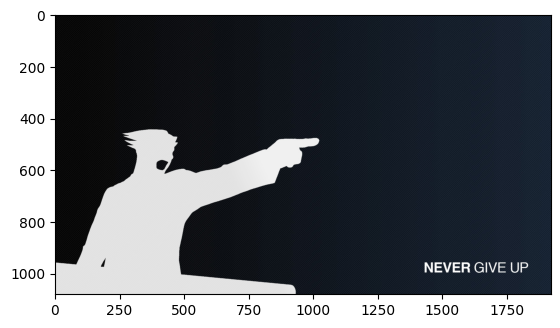

In [23]:
img_1_path = "/home/saurav/Desktop/get_the_text/ngu.jpg"
img_1 = implt.imread(img_1_path)
plt.imshow(img_1)
print(single_sample_prediction(pred_model, img_1_path))